# Transpilation and Qiskit Primitives

Up until now we have been working with circuits on a somewhat abstract level. We have built circuits with whatever combination of gates took our fancy, with however many qubits we wanted, and simply ran them on a simulator.

In this notebook we will learn how to convert our abstract representations of circuits into real, executable circuits on "real" hardware. 

Let's take a fake hardware backend and inspect some of it's limitations.

In [123]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

fake_backend = FakeManilaV2()
target = fake_backend.target

print(fake_backend.coupling_map)
print(target)

[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]]
Target
Number of qubits: 5
Instructions:
	measure
		(0,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0353
		(1,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0219
		(2,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0964
		(3,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0144
		(4,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0186
	sx
		(0,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000155066
		(1,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000392193
		(2,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000745816
		(3,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000212219
		(4,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000353872
	if_else
	for_loop
	cx
		(0, 1):
			Duration: 2.77333e-07 sec.
			Error Rate: 0.00882771
		(1, 0):
			Duration: 3.12889e-07 sec.
			Error Rate: 0.00882771
		(1, 2):
			Duration: 4.69333e-07 sec.
			Error Rate: 0.0139404
		(2, 1):
			Duration: 5.04889e-07 s

### So it seems our backend has only 5 qubits, they are not all-to-all connected (ie we cannot apply 2 qubits gates between any arbitrary pair of qubits), and we have a somewhat limited gate set. 

### How then can we run our circuits?

### For example, what if I want to apply a CNOT between qubit 0 and qubit 3?

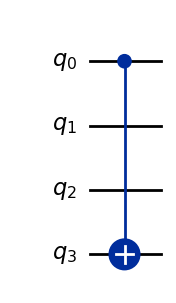

In [ ]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(4)
qc.cx(0, 3)

qc.draw(output='mpl')

## One way of accomplishing this could be to use SWAP gates

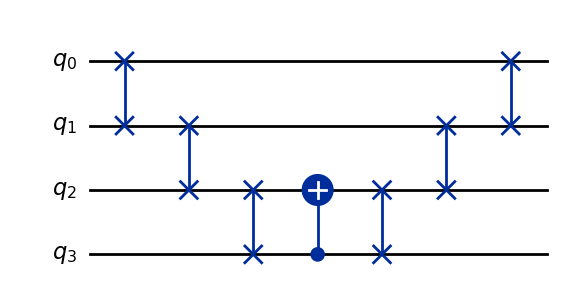

In [130]:
qc_4 = QuantumCircuit(4)

# Move qubit 0 next to qubit 3 using SWAPs
qc_4.swap(0, 1)
qc_4.swap(1, 2)
qc_4.swap(2, 3)

# Now qubit 0 is effectively at position 3
# Apply CX (now local, but at huge cost)
qc_4.cx(3, 2)  # control = original qubit 0, target = original qubit 3

# Swap everything back
qc_4.swap(2, 3)
qc_4.swap(1, 2)
qc_4.swap(0, 1)

qc_4.draw("mpl")

## And if our hardware backend doesn't support SWAP gates?

### It turns out the SWAP gate is equivalent to applying CNOT gates alternating the target and control qubit

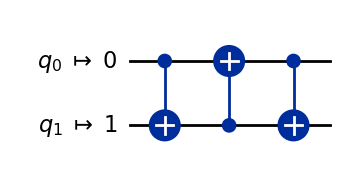

In [131]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

qc = QuantumCircuit(2)
qc.swap(0,1)
pm = generate_preset_pass_manager(target=target, optimization_level=0)
qc_transpiled = pm.run(qc)

qc_transpiled.draw("mpl")

### This is an example of a transpilation. We went from an abstract representation of an operation we wanted to apply (a swap gate), and converted it into operations that our hardware supports. 

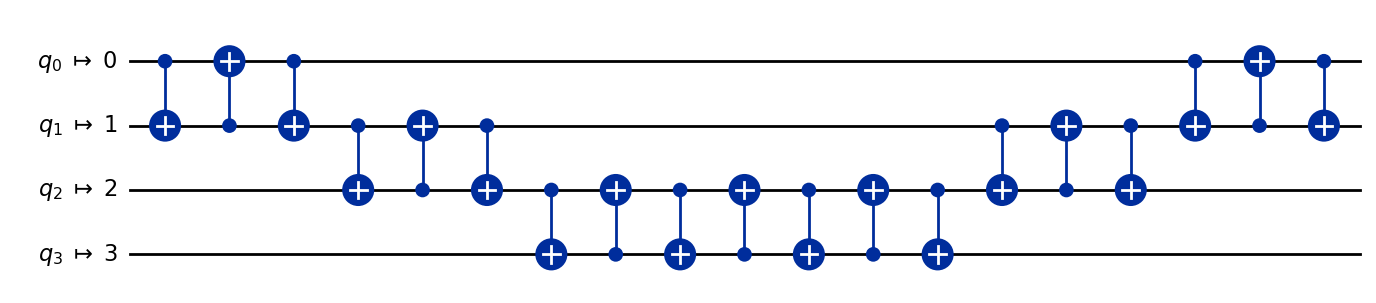

In [135]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=target, optimization_level=0)
qc_isa = pm.run(qc_4)

qc_isa.draw("mpl")

## `pass_managers` expose some of the transpilation steps and allow customization. However, you can also just use the `transpile` function.

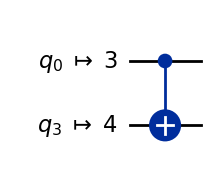

In [137]:
from qiskit import transpile

qc_transpiled = transpile(circuits=qc_4, target=target)
qc_transpiled.draw(output='mpl')

---

## Okay and what about other gates that aren't supported by our target backend? 

In [138]:
print(target.operation_names)

dict_keys(['measure', 'sx', 'if_else', 'for_loop', 'cx', 'rz', 'id', 'switch_case', 'delay', 'reset', 'x'])


# Y gate

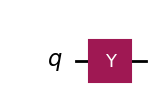

In [237]:
import numpy as np

qc = QuantumCircuit(1)
qc.y(0)

qc.draw(output='mpl')

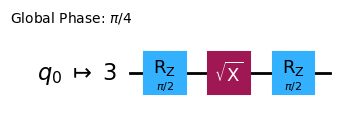

In [236]:
qc_transpiled = transpile(circuits=qc, target=target)
qc_transpiled.draw(output='mpl')

So in order to apply a Y gate, our transpiler first does a rotation about the Z axis by an angle of π radians (180°) and then an X gate. 

And what's that global phase thing in the corner?


$$
Y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix},
\quad
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix},
\quad
R_z(\pi) =
\begin{pmatrix}
-i & 0 \\
0 & i
\end{pmatrix}
$$

$$
X R_z(\pi)
=
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\begin{pmatrix}
-i & 0 \\
0 & i
\end{pmatrix}
=
\begin{pmatrix}
0 & i \\
-i & 0
\end{pmatrix}
$$

$$
X R_z(\pi) = -Y = e^{i\pi} Y
$$

We see mathetmatically that these two gates are equivalent to the Y gate (up to a global phase).

In quantum mechanics, we don't care about the global phase (a phase that applies over the entire state) because it doesn't affect observable outcomes. In other words, it makes no different to our measurements. 

---

# H gate

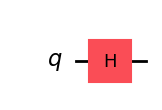

In [240]:
qc = QuantumCircuit(1)
qc.h(0)

qc.draw(output='mpl')

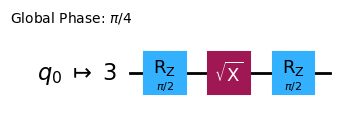

In [241]:
qc_transpiled = transpile(circuits=qc, target=target)
qc_transpiled.draw(output='mpl')

---
# Rx and Ry

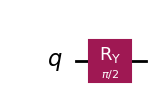

In [201]:
qc = QuantumCircuit(1)
qc.ry(np.pi/2, qubit=0)
qc.draw("mpl")

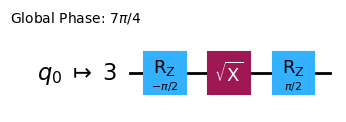

In [202]:
qc_transpiled = transpile(circuits=qc, target=target)
qc_transpiled.draw(output='mpl')

---
# Rzz

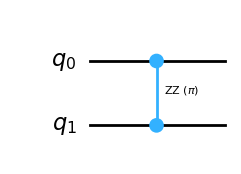

In [211]:
qc = QuantumCircuit(2)
qc.rzz(theta=np.pi ,qubit1=0, qubit2=1)

qc.draw(output='mpl')

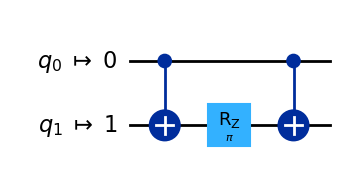

In [212]:
pm = generate_preset_pass_manager(target=target, optimization_level=0)
qc_isa = pm.run(qc)
 
qc_isa.draw("mpl")

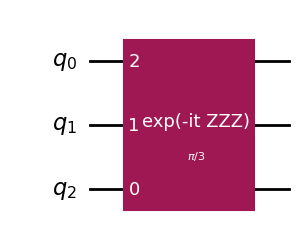

In [226]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Pauli

theta = np.pi/3
pauli_op = Pauli('ZZZ')
qc = QuantumCircuit(3)
rzzz = PauliEvolutionGate(pauli_op, time=theta)
qc.append(rzzz, [2,1,0])

qc.draw("mpl")

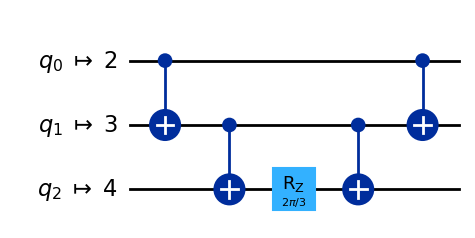

In [229]:
qc_transpiled = transpile(qc, target=target)
qc_transpiled.draw("mpl")

### Qiskit’s transpiler automatically converts any circuit into the native gates that a device can run. Gates that aren’t directly supported—like Y, RZZ, or multi-qubit rotations—are broken down into combinations of universal gates such as Rz and CX. 

### Because these gates form a universal gate set, we can build any circuit we want, and the transpiler takes care of mapping it to the hardware so it runs correctly.

## Exercise

1. Transpilation is a very nice feature of Qiskit but it can quickly proliferate. Implement some combinations of gates to see how many real gates are typically needed. Hint: CNOTs/SWAPs make a mess.

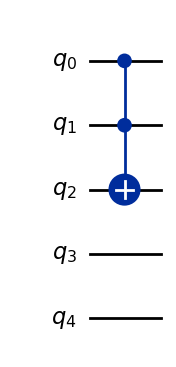

In [244]:
qc = QuantumCircuit(5)

# Mess around here - I'll get you started:
qc.ccx(0,1,2)
# qc.swap(3,4)
# qc.h(4)
# qc.sx(3)
# qc.cx(4,0)
# qc.h(2)
# qc.ccx(2,3,4)

qc.draw("mpl")

OrderedDict({'rz': 10, 'cx': 9, 'sx': 2})


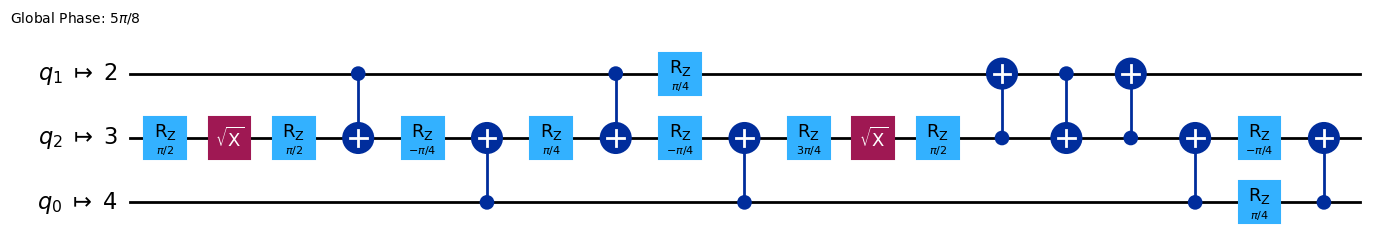

In [247]:
### Transpile here ###

qc_transpiled = transpile(qc, target=target)
print(qc_transpiled.count_ops())
qc_transpiled.draw("mpl")

---
# Primitives

# Sampler

### A "Sampler" is a primitive designed to sample possible states resulting from a quantum circuit, and collect statistics on what states might be measured and with what probability. We import the Qiskit Runtime Sampler here:

In [186]:
from qiskit.circuit import ClassicalRegister

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

creg = ClassicalRegister(2, "creg")
qc.add_register(creg)
qc.measure([0,1], creg)

qc_isa = transpile(qc, target=target)

counts = {'00': 505, '11': 519}


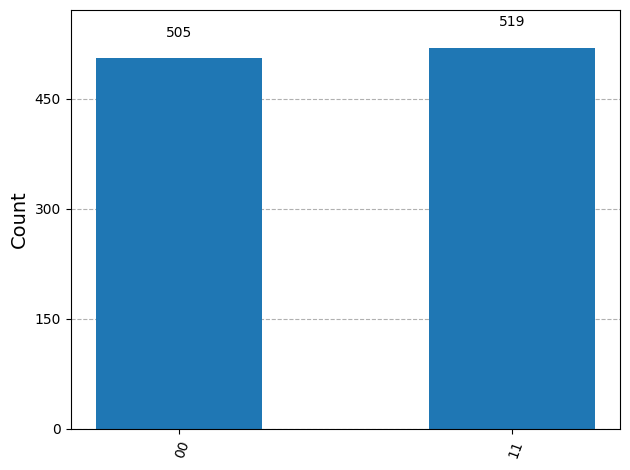

In [187]:
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2 as Sampler
from qiskit.visualization import plot_histogram

backend_sim = AerSimulator(noise_model=None)
sampler_sim = Sampler(backend=backend_sim)

job = sampler_sim.run([qc_isa], shots=1024)
results = job.result()

# Extract counts from your classical register
counts = results[0].data.creg.get_counts()  # <-- 'c' matches your ClassicalRegister name
print("counts =", counts)

plot_histogram(counts)

# Estimator

In [95]:
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendEstimatorV2 as Estimator
from qiskit.quantum_info import Pauli

backend_sim = AerSimulator()

# Create the Estimator
estimator = Estimator(backend=backend_sim)

# Define the observable
observable = Pauli("ZZIII")

# Run the estimator: pass a list of (circuit, observable) tuples
job = estimator.run([(qc_isa, observable)])
result = job.result()

In [97]:
# Access the first PubResult
pub_result = result[0]

# Extract expectation values from the DataBin
expvals = pub_result.data.evs  # this is a numpy array of shape (1,)

print("Expectation value:", expvals)

Expectation value: 1.0


# NEW

Sampler counts: {'00': 496, '11': 528}


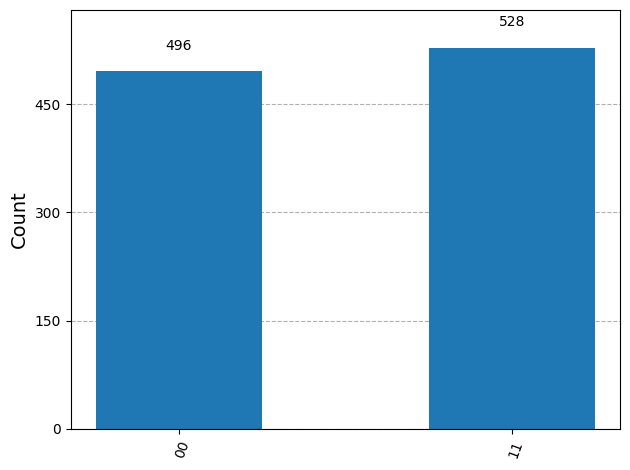

In [100]:
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit, ClassicalRegister
from qiskit.visualization import plot_histogram

# 1. Build a simple Bell circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

# 2. Make classical register to measure into
creg = ClassicalRegister(2, name="creg")
bell.add_register(creg)
bell.measure([0,1], cbit=creg)

# 2. Initialize sampler
sim = AerSimulator()
sampler = BackendSamplerV2(backend=sim)

# 3. Run and fetch results
job = sampler.run([bell], shots=1024)
res = job.result()

# 4. Extract counts (assume classical register is 'c')
counts = res[0].data.creg.get_counts()
print("Sampler counts:", counts)

plot_histogram(counts)